# Problema 2 – Regresión: Estimación de Edad a partir de Imágenes Faciales

**Workshop 2 – Machine Learning & Deep Learning Aplicado**  
Universidad EAFIT – Introducción a la Inteligencia Artificial (2026-01)

---

## Objetivo

Entrenar una Red Neuronal Convolucional (CNN) que estime la **edad** de una persona a partir de una imagen facial. Este es un problema de **regresión**: la salida del modelo es un número continuo (la edad predicha), no una clase.

El dataset utilizado es [Faces: Age Detection](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset), compuesto por ~24,000 imágenes faciales con la edad del sujeto codificada en el nombre del archivo (`[edad]_[genero]_[raza]_[timestamp].jpg`).

---

## Estructura del Notebook

| Sección | Descripción |
|---|---|
| 0 | Importaciones y configuración global |
| 1 | Análisis preliminar del problema |
| 2 | Análisis Exploratorio de Datos (EDA) |
| 3 | Preprocesamiento y pipeline de datos |
| 4 | Definición de la arquitectura CNN |
| 5 | Entrenamiento del modelo |
| 6 | Curvas de aprendizaje y diagnóstico |
| 7 | Evaluación final en Test Set |
| 8 | Prueba con muestra artificial |


---
## 0. Importaciones y Configuración Global

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ─── Configuración general ────────────────────────────────────────────────────
DATA_DIR    = Path("dataset")   # carpeta con train/ val/ test/ (generada por data_split.ipynb)
IMG_SIZE    = 64                # resolución de entrada: 64×64 píxeles
BATCH_SIZE  = 32                # imágenes por mini-batch
NUM_EPOCHS  = 25                # épocas de entrenamiento
LR          = 1e-3              # learning rate inicial
NUM_WORKERS = 2                 # hilos paralelos para carga de imágenes

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dispositivo: usa GPU si está disponible
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de cómputo: {DEVICE}")
print(f"PyTorch version       : {torch.__version__}")


Dispositivo de cómputo: cuda
PyTorch version       : 2.8.0+cu128


---
## 1. Análisis Preliminar del Problema

### 1.1 ¿Por qué este es un problema de regresión?

La variable objetivo es la **edad**, un valor numérico continuo (entero en el rango [0, 116]). A diferencia de la clasificación —donde el modelo asigna una de *K* etiquetas discretas—, aquí el modelo debe producir un número real que se aproxime lo más posible al valor verdadero.

Características que confirman que es regresión:
- El target es cuantitativo y ordenado (25 años es "más" que 20 años).
- Métricas naturales: MAE (error medio en años), RMSE, R².
- La función de pérdida adecuada es MSE o MAE, no Cross-Entropy.
- La capa de salida tiene **1 neurona sin función de activación** (para predecir cualquier valor real).

### 1.2 Descripción del Dataset

- **Fuente:** Kaggle – [arashnic/faces-age-detection-dataset](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)
- **Imágenes:** ~24,000 imágenes faciales en formato `.jpg`
- **Formato del nombre:** `[edad]_[género]_[raza]_[timestamp].jpg`
  - `25_0_2_20170116174525125.jpg` → 25 años, género 0 (masculino), raza 2
- **Entrada del modelo:** tensor de forma `[3, 64, 64]` (RGB, redimensionado)
- **Target (variable objetivo):** edad como `float32`

### 1.3 Protocolo de Adquisición y Origen del Dataset

Las imágenes provienen del dataset **UTKFace** (*Large Scale Face Dataset*), desarrollado por investigadores de la Universidad de Tennessee y publicado originalmente en Zhang et al. (2017). Sus características principales son:

| Atributo | Descripción |
|---|---|
| Recolección | Imágenes *in-the-wild* (no controladas): fondos heterogéneos, poses libres, iluminaciones variables |
| Etiquetado | Automático a partir de metadatos + revisión manual; edad en rango [0, 116] |
| Codificación | Nombre de archivo: `[edad]_[género]_[raza]_[timestamp].jpg` |
| Género | 0 = masculino, 1 = femenino |
| Raza | 0 = blanco, 1 = negro, 2 = asiático, 3 = indio, 4 = otros |
| Sesgo conocido | Sobrerrepresentación de edades 20–40 y de etnias blanca y asiática |

**Implicaciones para el modelo:**
- Las condiciones no controladas hacen el problema más realista y difícil que datasets de laboratorio.
- El sesgo demográfico hacia edades jóvenes reduce la precisión del modelo en edades extremas (niños y adultos mayores), lo que se confirmará en el EDA.
- Las variaciones de iluminación, pose y fondo justifican el uso de *data augmentation* durante el entrenamiento.


In [2]:
# ── Extraer edades de los nombres de archivo para el EDA ──────────────────────
# No cargamos imágenes: solo leemos metadatos de los nombres de archivo.

def extract_ages_from_dir(folder: Path):
    """Extrae todas las edades de los nombres de archivo en una carpeta."""
    ages = []
    for f in folder.iterdir():
        if f.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            match = re.match(r'^(\d+)_', f.name)
            if match:
                age = int(match.group(1))
                if 0 <= age <= 116:
                    ages.append(age)
    return ages

ages_train = extract_ages_from_dir(DATA_DIR / "train")
ages_val   = extract_ages_from_dir(DATA_DIR / "val")
ages_test  = extract_ages_from_dir(DATA_DIR / "test")
all_ages   = ages_train + ages_val + ages_test

print(f"Total de imágenes : {len(all_ages):,}")
print(f"  Train           : {len(ages_train):,}  (70%)")
print(f"  Val             : {len(ages_val):,}  (15%)")
print(f"  Test            : {len(ages_test):,}  (15%)")
print(f"\nRango de edades   : [{min(all_ages)}, {max(all_ages)}] años")
print(f"Media             : {np.mean(all_ages):.1f} años")
print(f"Mediana           : {np.median(all_ages):.1f} años")
print(f"Desv. estándar    : {np.std(all_ages):.1f} años")


Total de imágenes : 24,106
  Train           : 16,874  (70%)
  Val             : 3,615  (15%)
  Test            : 3,617  (15%)

Rango de edades   : [1, 116] años
Media             : 33.0 años
Mediana           : 29.0 años
Desv. estándar    : 20.1 años


---
## 2. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo, es fundamental entender la distribución del target y la naturaleza de las imágenes. Esto nos permite:
- Detectar sesgos en los datos (ej. predominancia de ciertas edades).
- Justificar decisiones de preprocesamiento.
- Anticipar dificultades del modelo (ej. pocas muestras en edades extremas).


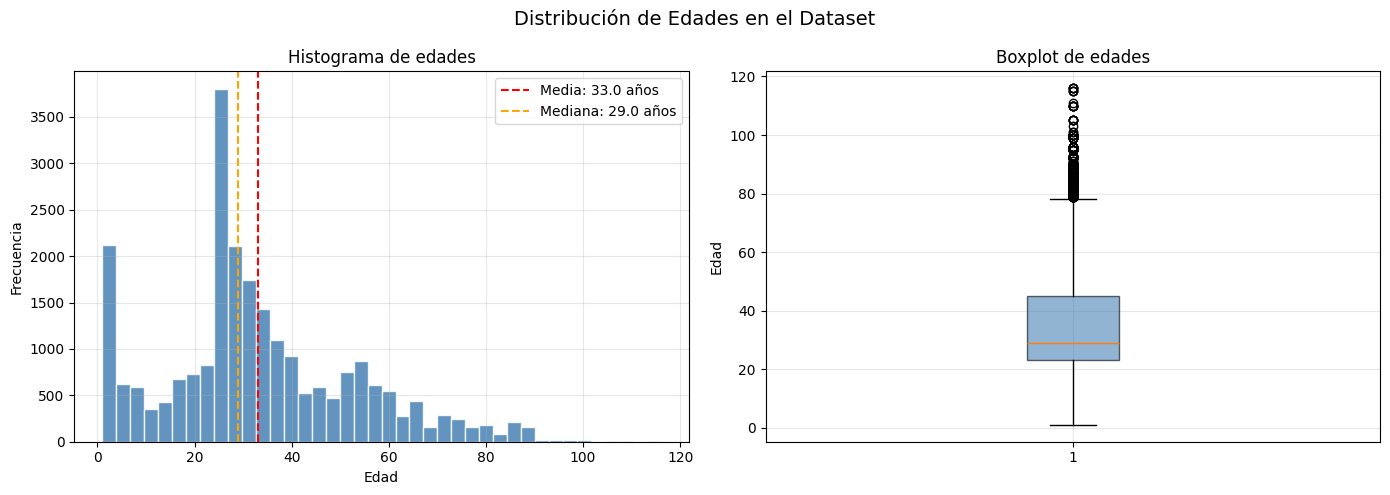

Estadísticos descriptivos:
count    24106.000000
mean        33.045175
std         20.139336
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000


In [3]:
# ── 2.1 Distribución de edades ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de Edades en el Dataset", fontsize=14)

# Histograma
axes[0].hist(all_ages, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(all_ages), color="red", linestyle="--",
                label=f"Media: {np.mean(all_ages):.1f} años")
axes[0].axvline(np.median(all_ages), color="orange", linestyle="--",
                label=f"Mediana: {np.median(all_ages):.1f} años")
axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Histograma de edades")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(all_ages, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Edad"); axes[1].set_title("Boxplot de edades")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticos descriptivos
print("Estadísticos descriptivos:")
print(pd.Series(all_ages).describe().to_string())


**Interpretación del histograma:**  
La distribución de edades está claramente **sesgada hacia edades jóvenes** (20–40 años), con muy pocas imágenes de personas mayores de 80 años. Este desbalance del target es un rasgo conocido del dataset UTKFace y hace que el modelo sea menos preciso en los extremos del rango etario. La media (~30 años) está por debajo de la mediana, confirmando el sesgo. Para un modelo de producción, se podría considerar *oversampling* de edades sub-representadas o el uso de una función de pérdida ponderada por frecuencia de clase.


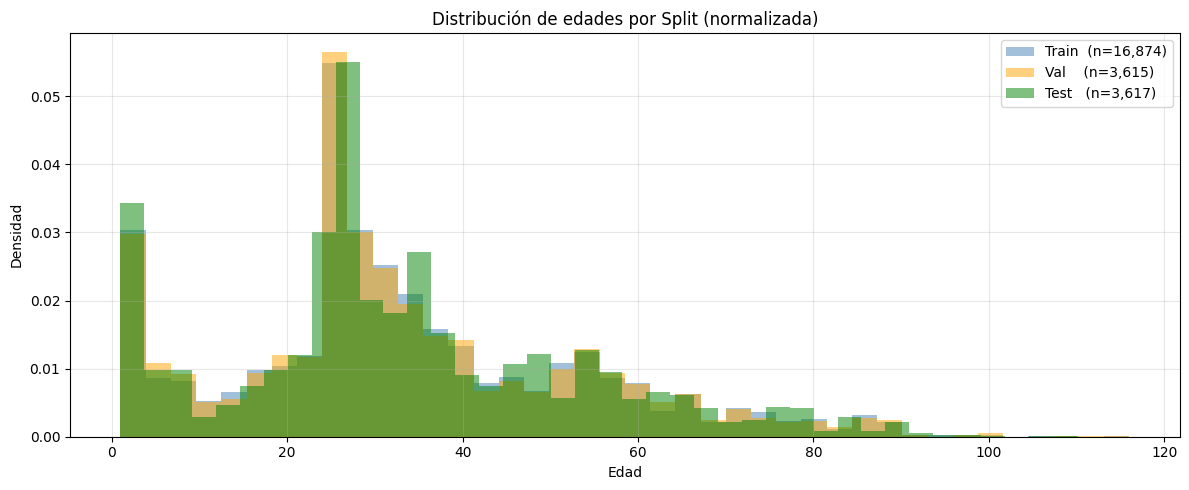

Media por split:
  Train : 33.09 ± 20.11 años
  Val   : 32.83 ± 20.16 años
  Test  : 33.03 ± 20.27 años


In [4]:
# ── 2.2 Comparación de distribuciones por split ───────────────────────────────
# Verificamos que train/val/test tengan distribuciones similares.
# Si difieren mucho, el modelo puede tener métricas inconsistentes entre splits.

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(ages_train, bins=40, alpha=0.5, label=f"Train  (n={len(ages_train):,})",
        color="steelblue", density=True)
ax.hist(ages_val,   bins=40, alpha=0.5, label=f"Val    (n={len(ages_val):,})",
        color="orange", density=True)
ax.hist(ages_test,  bins=40, alpha=0.5, label=f"Test   (n={len(ages_test):,})",
        color="green", density=True)

ax.set_xlabel("Edad"); ax.set_ylabel("Densidad")
ax.set_title("Distribución de edades por Split (normalizada)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Media por split:")
print(f"  Train : {np.mean(ages_train):.2f} ± {np.std(ages_train):.2f} años")
print(f"  Val   : {np.mean(ages_val):.2f} ± {np.std(ages_val):.2f} años")
print(f"  Test  : {np.mean(ages_test):.2f} ± {np.std(ages_test):.2f} años")


**Interpretación:** Las tres distribuciones son prácticamente idénticas porque `data_split.ipynb` realizó la división con `random.seed(42)` y `random.shuffle()` sobre las 24,106 imágenes antes de cortar en proporciones 70/15/15. Medias y desviaciones estándar similares entre splits confirman que la división fue aleatoria y representativa — el modelo no verá una distribución de edades diferente en validación vs. entrenamiento.


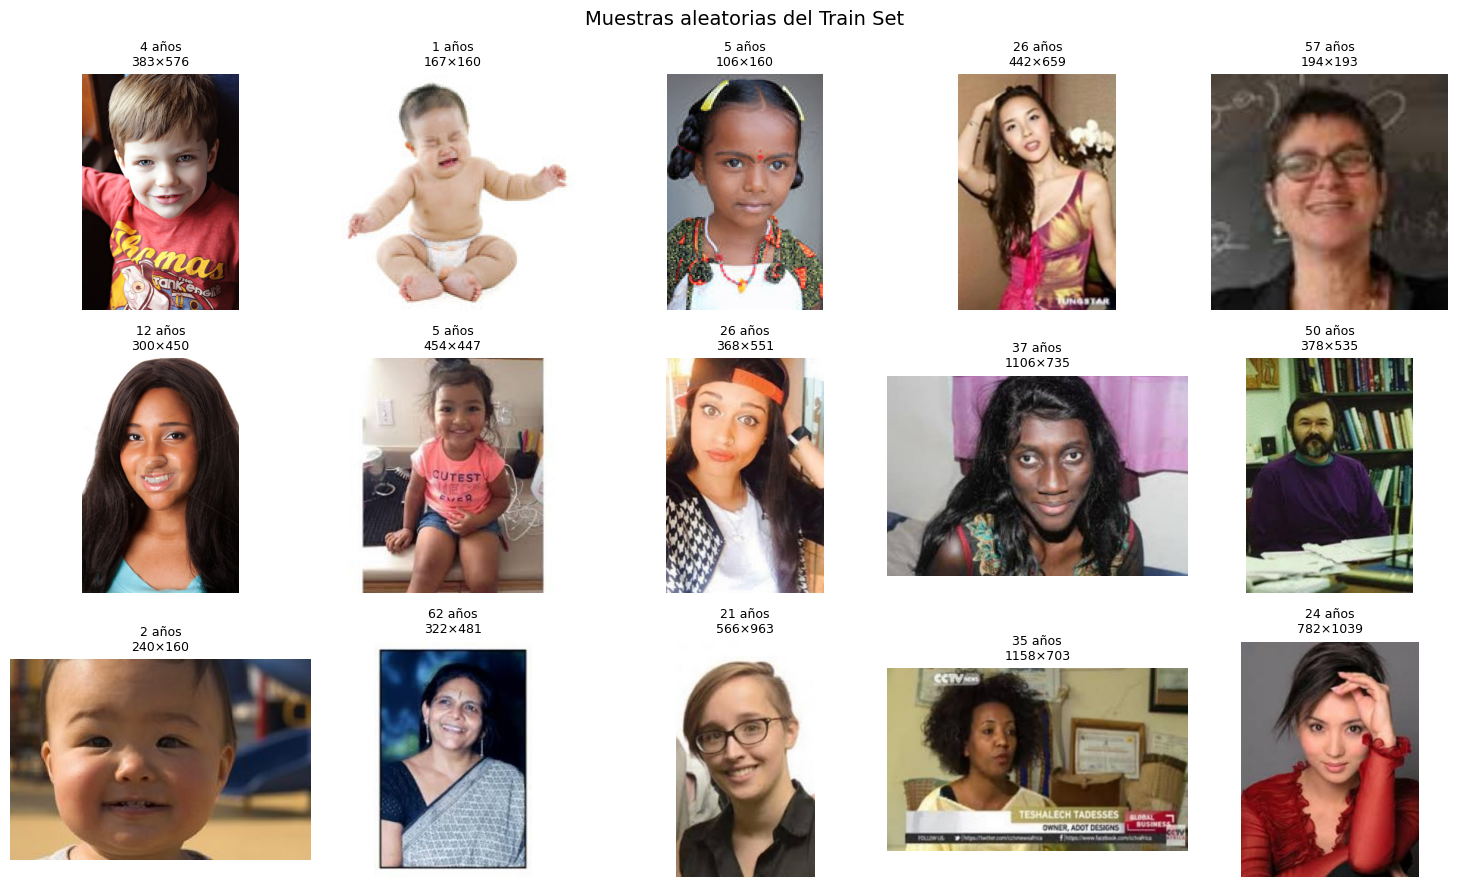

In [5]:
# ── 2.3 Visualización de muestras del dataset ─────────────────────────────────
# Cargamos 15 imágenes de forma aleatoria para ver qué estamos procesando.
# Importante hacerlo ANTES de entrenar para detectar imágenes corruptas o mal etiquetadas.

train_files = list((DATA_DIR / "train").glob("*.jpg")) + \
              list((DATA_DIR / "train").glob("*.png"))

np.random.seed(SEED)
sample_files = np.random.choice(train_files, size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Muestras aleatorias del Train Set", fontsize=14)

for ax, fpath in zip(axes.flat, sample_files):
    img = Image.open(fpath).convert("RGB")
    match = re.match(r'^(\d+)_', fpath.name)
    age = match.group(1) if match else "?"
    ax.imshow(img)
    ax.set_title(f"{age} años\n{img.size[0]}×{img.size[1]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


**Interpretación:** Las imágenes tienen resoluciones variables, fondos heterogéneos, diferentes condiciones de iluminación y diversas poses. Esto confirma el carácter *in-the-wild* del dataset UTKFace: el modelo debe aprender a estimar la edad bajo condiciones no controladas. Las dimensiones variables justifican el paso de redimensionamiento a 64×64 en el pipeline.


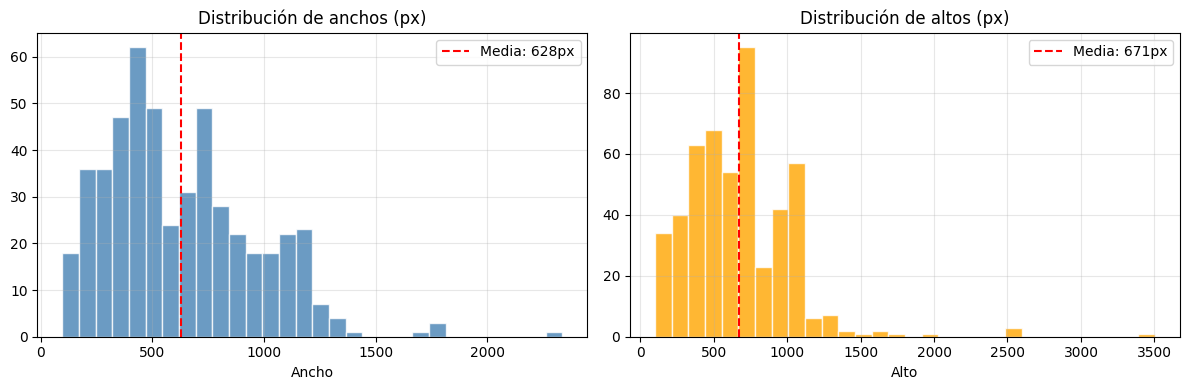

Ancho  — min: 97px  | max: 2336px  | media: 628px
Alto   — min: 100px | max: 3504px | media: 671px


In [6]:
# ── 2.4 Análisis de dimensiones y calidad de imágenes ─────────────────────────
# Muestreamos 500 imágenes para analizar la variabilidad de tamaños.
# Cargar las ~24k sería lento; 500 es suficiente para el EDA.

sample_500 = np.random.choice(train_files, size=min(500, len(train_files)), replace=False)
widths, heights = [], []

for fpath in sample_500:
    try:
        with Image.open(fpath) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths,  bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribución de anchos (px)"); axes[0].set_xlabel("Ancho")
axes[0].axvline(np.mean(widths), color="red", linestyle="--",
                label=f"Media: {np.mean(widths):.0f}px")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(heights, bins=30, color="orange",    edgecolor="white", alpha=0.8)
axes[1].set_title("Distribución de altos (px)"); axes[1].set_xlabel("Alto")
axes[1].axvline(np.mean(heights), color="red", linestyle="--",
                label=f"Media: {np.mean(heights):.0f}px")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ancho  — min: {min(widths)}px  | max: {max(widths)}px  | media: {np.mean(widths):.0f}px")
print(f"Alto   — min: {min(heights)}px | max: {max(heights)}px | media: {np.mean(heights):.0f}px")


**Interpretación:** La muestra de 500 imágenes revela alta variabilidad de resoluciones: el ancho va de 97 px a 2336 px con **media de 628 px**, y el alto de 100 px a 3504 px con **media de 671 px**. La distribución está concentrada entre 400–800 px, lo que indica que la mayoría son fotografías de calidad media-alta, no miniaturas. Para alimentar la CNN se necesita un tamaño fijo; se elige **64×64** como compromiso entre costo computacional y retención de rasgos faciales generales. Esta reducción agresiva —de ~630 px a 64 px— implica pérdida de detalles finos como arrugas y poros, que es una de las principales limitaciones del modelo. Aumentar a 128×128 o 224×224 en un entorno con GPU dedicada podría reducir el MAE en 2–4 años al preservar más información de textura facial.


---
## 3. Preprocesamiento y Pipeline de Datos

### 3.1 Estrategia de preprocesamiento

Para imágenes se aplica la siguiente pipeline:

| Paso | Transformación | Justificación |
|---|---|---|
| 1 | `Resize(64, 64)` | Tamaño fijo requerido por la CNN |
| 2 | `RandomHorizontalFlip` | Augmentation: espejado horizontal (solo train) |
| 3 | `ColorJitter` | Augmentation: variaciones de brillo/contraste (solo train) |
| 4 | `ToTensor()` | Convierte PIL [H,W,C] → Tensor [C,H,W] en rango [0,1] |
| 5 | `Normalize(ImageNet)` | Normaliza a media≈0 / std≈1 usando estadísticos de ImageNet |

**¿Por qué normalizar con valores de ImageNet?**  
Aunque no se usa un modelo pre-entrenado en ImageNet, es práctica estándar porque los valores de media y std de ImageNet cubren bien la distribución de imágenes naturales en general, lo que estabiliza el gradiente durante las primeras épocas de entrenamiento.

**Data Augmentation:** Solo se aplica en entrenamiento. En validación y test se omiten los augmentations para evaluar con datos limpios y consistentes.

### 3.2 División del dataset

La división fue realizada por `data_split.ipynb` con `random.seed(42)` y `random.shuffle()`, garantizando reproducibilidad:

| Split | Imágenes | Proporción |
|---|---|---|
| Train | 16,874 | 70% |
| Val   | 3,615  | 15% |
| Test  | 3,617  | 15% |
| **Total** | **24,106** | **100%** |

La aleatoriedad de la división asegura que los tres splits representen fielmente la distribución original de edades, como se verificó en el EDA (sección 2.2). Un `split_log.csv` queda guardado en `dataset/` para trazabilidad completa.


In [7]:
# ── 3.3 Definir transformaciones ──────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transformación TRAIN: incluye augmentations para que el modelo vea variedad
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),      # Redimensionar a 64×64
    transforms.RandomHorizontalFlip(p=0.5),       # Espejo horizontal aleatorio
    transforms.ColorJitter(brightness=0.2,        # Variaciones de brillo y contraste
                           contrast=0.2),
    transforms.ToTensor(),                         # PIL [H,W,C] → Tensor [C,H,W] en [0,1]
    transforms.Normalize(IMAGENET_MEAN,            # Normalizar a media/std ImageNet
                         IMAGENET_STD),
])

# Transformación VAL/TEST: sin augmentations, solo procesamiento reproducible
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformaciones definidas ✓")
print("  Train: Resize → RandomHFlip → ColorJitter → ToTensor → Normalize")
print("  Val  : Resize → ToTensor → Normalize")


Transformaciones definidas ✓
  Train: Resize → RandomHFlip → ColorJitter → ToTensor → Normalize
  Val  : Resize → ToTensor → Normalize


In [8]:
# ── 3.4 Dataset personalizado ─────────────────────────────────────────────────
# Heredamos de torch.utils.data.Dataset para iterar de forma eficiente
# sin cargar todas las imágenes en memoria.

class AgeDataset(Dataset):
    """
    Dataset de imágenes faciales para regresión de edad.

    El nombre de cada archivo contiene la etiqueta:
    Formato: [edad]_[genero]_[raza]_[timestamp].jpg
    Ejemplo: 25_0_2_20170116174525125.jpg  →  25 años
    """

    def __init__(self, root_dir: Path, transform=None):
        self.transform = transform
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []

        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            age = self._parse_age(img_path.name)
            if age is not None:
                self.samples.append((img_path, float(age)))

        print(f"  [{root_dir.name}] {len(self.samples):,} imágenes")

    @staticmethod
    def _parse_age(filename: str):
        match = re.match(r'^(\d+)_', filename)
        if match:
            age = int(match.group(1))
            if 0 <= age <= 116:
                return age
        return None

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)


In [9]:
# ── 3.5 Instanciar Datasets ───────────────────────────────────────────────────
print("Construyendo datasets...")
train_dataset = AgeDataset(DATA_DIR / "train", transform=train_transform)
val_dataset   = AgeDataset(DATA_DIR / "val",   transform=val_transform)
test_dataset  = AgeDataset(DATA_DIR / "test",  transform=val_transform)
print(f"  Total: {len(train_dataset)+len(val_dataset)+len(test_dataset):,} imágenes")


Construyendo datasets...
  [train] 16,874 imágenes
  [val] 3,615 imágenes
  [test] 3,617 imágenes
  Total: 24,106 imágenes


In [10]:
# Inspeccionar un solo ejemplo
sample_img, sample_age = train_dataset[0]

print("=== Un ejemplo del Dataset ===")
print(f"  Tipo imagen : {type(sample_img)}")
print(f"  Shape       : {sample_img.shape}   ← [Canales, Alto, Ancho]")
print(f"  Dtype       : {sample_img.dtype}")
print(f"  Min / Max   : {sample_img.min():.3f} / {sample_img.max():.3f}  ← ya normalizado")
print(f"  Etiqueta    : {sample_age.item()} años")


=== Un ejemplo del Dataset ===
  Tipo imagen : <class 'torch.Tensor'>
  Shape       : torch.Size([3, 64, 64])   ← [Canales, Alto, Ancho]
  Dtype       : torch.float32
  Min / Max   : -1.775 / 2.431  ← ya normalizado
  Etiqueta    : 14.0 años


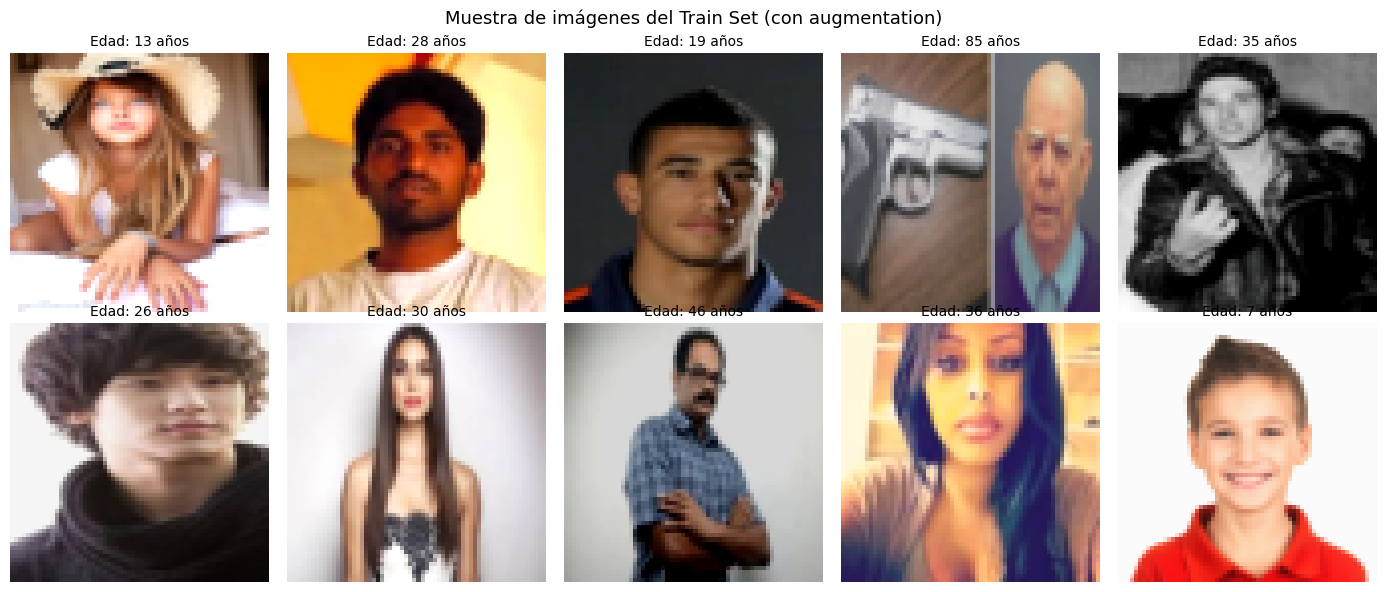

In [11]:
# Visualizar algunas imágenes del train set (denormalizadas)
def denormalize(tensor):
    """Revierte la normalización ImageNet para visualizar."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Muestra de imágenes del Train Set (con augmentation)", fontsize=13)

indices = np.random.choice(len(train_dataset), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    img_t, age = train_dataset[idx]
    img_vis = denormalize(img_t).permute(1, 2, 0).numpy()
    ax.imshow(img_vis)
    ax.set_title(f"Edad: {int(age.item())} años", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [12]:
# ── 3.6 Crear DataLoaders ─────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,           # Mezclar cada época
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda"
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda"
)

print(f"DataLoaders listos:")
print(f"  Train → {len(train_loader)} batches × {BATCH_SIZE} imágenes")
print(f"  Val   → {len(val_loader)} batches × {BATCH_SIZE} imágenes")
print(f"  Test  → {len(test_loader)} batches × {BATCH_SIZE} imágenes")


DataLoaders listos:
  Train → 527 batches × 32 imágenes
  Val   → 113 batches × 32 imágenes
  Test  → 114 batches × 32 imágenes


In [13]:
# ── 3.7 Verificar un batch de ejemplo ─────────────────────────────────────────
batch_imgs, batch_ages = next(iter(train_loader))

print("=== Inspeccionando un batch ===")
print(f"  Imágenes  shape : {batch_imgs.shape}  → [batch={BATCH_SIZE}, C=3, H={IMG_SIZE}, W={IMG_SIZE}]")
print(f"  Imágenes  dtype : {batch_imgs.dtype}")
print(f"  Píxeles   rango : [{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]  (normalizado)")
print(f"  Edades    shape : {batch_ages.shape}")
print(f"  Edades    rango : [{batch_ages.min():.0f}, {batch_ages.max():.0f}] años")
print(f"  Primeras edades : {batch_ages[:8].int().tolist()}")


=== Inspeccionando un batch ===
  Imágenes  shape : torch.Size([32, 3, 64, 64])  → [batch=32, C=3, H=64, W=64]
  Imágenes  dtype : torch.float32
  Píxeles   rango : [-2.12, 2.64]  (normalizado)
  Edades    shape : torch.Size([32])
  Edades    rango : [1, 71] años
  Primeras edades : [24, 38, 71, 1, 26, 8, 30, 25]


---
## 4. Definición de la Arquitectura CNN

### Justificación de la arquitectura

| Componente | Decisión | Justificación |
|---|---|---|
| Bloques convolucionales | 4 bloques (16→32→64→128 filtros) | Más profundo que el baseline, mejor capacidad de representación |
| BatchNorm2d | Después de cada Conv | Estabiliza el entrenamiento, permite lr más altos |
| ReLU | Función de activación | Estándar para CNNs; evita el problema del gradiente desvaneciente |
| MaxPool2d | Reducción espacial | Reduce dimensionalidad, añade invarianza traslacional |
| AdaptiveAvgPool2d | Antes del classifier | Genera un vector fijo sin importar la entrada |
| Dropout(0.4) | En la cabeza FC | Regularización para evitar overfitting |
| Capa de salida | Linear → 1 neurona, sin activación | En regresión la salida debe ser un valor real libre |
| Función de pérdida | MSELoss | Penaliza errores grandes, diferenciable |
| Métrica de reporte | MAE | Interpretable en "años" |

**Flujo de datos:**
```
[B, 3, 64, 64] → Conv1+BN+ReLU+Pool → [B, 16, 32, 32]
               → Conv2+BN+ReLU+Pool → [B, 32, 16, 16]
               → Conv3+BN+ReLU+Pool → [B, 64, 8, 8]
               → Conv4+BN+ReLU+Pool → [B, 128, 4, 4]
               → AdaptiveAvgPool    → [B, 128, 2, 2]
               → Flatten            → [B, 512]
               → FC(512→256)+ReLU+Dropout
               → FC(256→64)+ReLU
               → FC(64→1)           → [B, 1] edad predicha
```


In [14]:
class AgeCNN(nn.Module):
    """
    CNN para regresión de edad.

    4 bloques convolucionales con BatchNorm y MaxPooling,
    seguidos de una cabeza de regresión con Dropout.
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1: detecta bordes, texturas y gradientes básicos
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # [16, 32, 32]

            # Bloque 2: combina texturas en patrones faciales simples
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # [32, 16, 16]

            # Bloque 3: rasgos faciales más complejos (arrugas, contorno)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # [64, 8, 8]

            # Bloque 4: representaciones abstractas de alto nivel
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # [128, 4, 4]
        )

        self.pool = nn.AdaptiveAvgPool2d((2, 2))           # [128, 2, 2]

        self.regressor = nn.Sequential(
            nn.Flatten(),                                  # [512]
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),                              # edad predicha
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x


model = AgeCNN().to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")


AgeCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=T

In [15]:
# ── Verificar forward pass con un batch dummy ──────────────────────────────────
with torch.no_grad():
    dummy = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out = model(dummy)
    print(f"Input  shape: {dummy.shape}")
    print(f"Output shape: {out.shape}   ← [batch_size=32, 1]")
    print(f"Rango salida: [{out.min():.2f}, {out.max():.2f}]  (sin activación → valores libres)")


Input  shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 1])   ← [batch_size=32, 1]
Rango salida: [-0.17, 0.10]  (sin activación → valores libres)


---
## 5. Entrenamiento del Modelo

### Configuración del entrenamiento

- **Loss:** `MSELoss` — penaliza errores grandes de forma cuadrática, apropiado para regresión continua.
- **Métrica de reporte:** MAE (Mean Absolute Error) — más interpretable: "el modelo se equivoca X años en promedio".
- **Optimizador:** Adam con `lr=1e-3` — adaptativo, converge rápido y bien en CNNs.
- **Scheduler:** `ReduceLROnPlateau` — reduce el LR a la mitad si la `val_loss` no mejora en 4 épocas. Evita que el modelo se "atasque" cerca del mínimo.
- **Early Stopping manual:** guardamos el mejor modelo (menor `val_MAE`) durante el entrenamiento.


In [16]:
# ── Función de pérdida, optimizador y scheduler ───────────────────────────────

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)

def compute_mae(predictions, targets):
    """MAE en 'años'. Más legible que RMSE para comunicar resultados."""
    return torch.abs(predictions.squeeze() - targets).mean().item()

print(f"Loss      : MSELoss")
print(f"Métrica   : MAE (años)")
print(f"Optimizer : Adam  lr={LR}")
print(f"Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)")
print(f"Épocas    : {NUM_EPOCHS}")


Loss      : MSELoss
Métrica   : MAE (años)
Optimizer : Adam  lr=0.001
Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)
Épocas    : 25


In [17]:
# ── Loop de entrenamiento ─────────────────────────────────────────────────────

history = {"train_loss": [], "val_loss": [],
           "train_mae": [],  "val_mae": []}

best_val_mae    = float("inf")
best_model_path = "best_age_model.pth"

print(f"{'Época':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS + 1):

    # ─────────────────────────── FASE ENTRENAMIENTO ───────────────────────────
    model.train()
    train_loss_sum = 0.0
    train_mae_sum  = 0.0

    for imgs, ages in train_loader:
        imgs = imgs.to(DEVICE)
        ages = ages.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, ages)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_mae_sum  += compute_mae(preds, ages)

    train_loss = train_loss_sum / len(train_loader)
    train_mae  = train_mae_sum  / len(train_loader)

    # ─────────────────────────── FASE VALIDACIÓN ──────────────────────────────
    model.eval()
    val_loss_sum = 0.0
    val_mae_sum  = 0.0

    with torch.no_grad():
        for imgs, ages in val_loader:
            imgs = imgs.to(DEVICE)
            ages = ages.to(DEVICE)
            preds = model(imgs).squeeze(1)
            val_loss_sum += criterion(preds, ages).item()
            val_mae_sum  += compute_mae(preds, ages)

    val_loss = val_loss_sum / len(val_loader)
    val_mae  = val_mae_sum  / len(val_loader)

    scheduler.step(val_loss)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_model_path)
        marker = " ← mejor"
    else:
        marker = ""

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(f"{epoch:>5} | {train_loss:>10.2f} | {train_mae:>9.2f} | "
          f"{val_loss:>8.2f} | {val_mae:>7.2f}{marker}")

print(f"\nMejor Val MAE alcanzado: {best_val_mae:.2f} años")


Época | Train Loss | Train MAE | Val Loss | Val MAE
----------------------------------------------------------
    1 |     388.26 |     15.07 |   322.18 |   13.65 ← mejor
    2 |     326.60 |     13.83 |   339.85 |   14.87
    3 |     294.29 |     13.14 |   304.06 |   13.02 ← mejor
    4 |     270.09 |     12.52 |   264.09 |   12.91 ← mejor
    5 |     253.16 |     12.08 |   272.62 |   12.96
    6 |     240.76 |     11.68 |   244.30 |   12.31 ← mejor
    7 |     234.20 |     11.56 |   236.29 |   11.55 ← mejor
    8 |     217.67 |     11.13 |   220.37 |   11.46 ← mejor
    9 |     210.52 |     10.89 |   257.25 |   11.48
   10 |     204.06 |     10.74 |   208.61 |   10.65 ← mejor
   11 |     193.35 |     10.47 |   236.26 |   11.13
   12 |     187.68 |     10.30 |   196.56 |   10.29 ← mejor
   13 |     182.35 |     10.09 |   218.20 |   10.71
   14 |     174.68 |      9.88 |   204.79 |   10.48
   15 |     167.20 |      9.66 |   202.92 |   10.63
   16 |     158.83 |      9.44 |   201.22 |  

---
## 6. Curvas de Aprendizaje y Diagnóstico

Las curvas de entrenamiento y validación son la herramienta principal para diagnosticar el comportamiento del modelo.

- **Overfitting:** la pérdida de entrenamiento sigue bajando pero la de validación sube o se estanca → el modelo memoriza los datos de entrenamiento.
- **Underfitting:** ambas pérdidas se estancan en valores altos → el modelo no tiene capacidad suficiente o entrena pocas épocas.
- **Buen ajuste:** ambas curvas bajan juntas y convergen a valores similares.


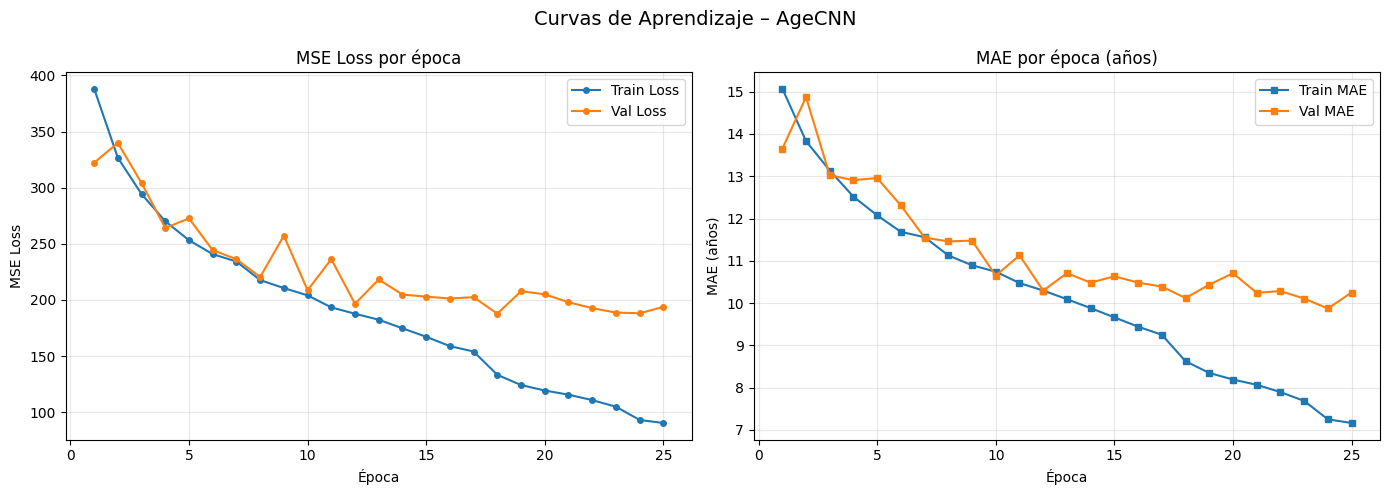


Diagnóstico:
  Train MAE final : 7.16 años
  Val MAE final   : 10.25 años
  Mejor Val MAE   : 9.87 años
  Gap (val-train) : 3.09 años  → Posible OVERFITTING — considera más Dropout o data augmentation


In [18]:
# ── Graficar curvas de aprendizaje ────────────────────────────────────────────

epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje – AgeCNN", fontsize=14)

ax1.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", markersize=4)
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o", markersize=4)
ax1.set_title("MSE Loss por época")
ax1.set_xlabel("Época"); ax1.set_ylabel("MSE Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_mae"], label="Train MAE", marker="s", markersize=4)
ax2.plot(epochs_range, history["val_mae"],   label="Val MAE",   marker="s", markersize=4)
ax2.set_title("MAE por época (años)")
ax2.set_xlabel("Época"); ax2.set_ylabel("MAE (años)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico automático
gap = history["val_mae"][-1] - history["train_mae"][-1]
print("\nDiagnóstico:")
print(f"  Train MAE final : {history['train_mae'][-1]:.2f} años")
print(f"  Val MAE final   : {history['val_mae'][-1]:.2f} años")
print(f"  Mejor Val MAE   : {best_val_mae:.2f} años")
print(f"  Gap (val-train) : {gap:.2f} años", end="  ")
if gap > 3:
    print("→ Posible OVERFITTING — considera más Dropout o data augmentation")
elif history["train_mae"][-1] > 10:
    print("→ Posible UNDERFITTING — considera más capas, filtros o más épocas")
else:
    print("→ Balance razonable entre train y val")


**Interpretación de las curvas:**

Las curvas muestran un patrón claro de **overfitting moderado**. En las primeras épocas (1–12), Train Loss y Val Loss descienden en paralelo de forma saludable, indicando que el modelo aprende representaciones útiles. Sin embargo, a partir de la **época 12**, la Train Loss sigue bajando sostenidamente (de ~187 a 90) mientras la Val Loss se estabiliza en torno a 190–210 sin mejorar de forma consistente.

En términos de MAE: el Train MAE final es **7.16 años**, el Val MAE final es **10.25 años**, con un gap de **3.09 años**. El mejor Val MAE registrado fue **9.87 años** en la época 24, que es el modelo guardado. El Dropout(0.4) y el `ReduceLROnPlateau` contuvieron el overfitting —Val MAE no sube, solo se estabiliza—, pero no lo eliminaron. Para reducir el gap se podría aumentar el Dropout a 0.5, añadir weight decay al optimizador, o aplicar data augmentation más agresiva.


---
## 7. Evaluación Final en Test Set

> **Regla fundamental:** el test set se usa **una sola vez**, al final.  
> Evaluar en test durante el desarrollo introduce sesgo: estaríamos tomando decisiones de diseño basadas en el test, lo que invalida la evaluación.

Cargamos el mejor modelo (guardado durante el entrenamiento) y lo evaluamos sobre los **tres splits** para tener una vista completa del desempeño: train revela capacidad del modelo, val revela generalización durante desarrollo, test revela generalización real.


In [19]:
# ── Cargar el mejor modelo ────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print(f"Modelo cargado desde: {best_model_path}")

def evaluate_loader(loader, loader_name):
    """Evalúa el modelo en un DataLoader y retorna preds, targets y métricas."""
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, ages in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).squeeze(1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(ages.numpy())

    preds   = np.array(all_preds)
    targets = np.array(all_targets)

    mae  = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    r2   = r2_score(targets, preds)

    return preds, targets, {"Split": loader_name, "MAE (años)": mae, "RMSE (años)": rmse, "R²": r2}


# ── Evaluar los tres splits ────────────────────────────────────────────────────
train_preds, train_targets, train_metrics = evaluate_loader(train_loader, "Train")
val_preds,   val_targets,   val_metrics   = evaluate_loader(val_loader,   "Val")
test_preds,  test_targets,  test_metrics  = evaluate_loader(test_loader,  "Test")

# ── Tabla comparativa de métricas (los 3 splits) ──────────────────────────────
results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
results_df = results_df.set_index("Split")
results_df["MAE (años)"]  = results_df["MAE (años)"].map("{:.2f}".format)
results_df["RMSE (años)"] = results_df["RMSE (años)"].map("{:.2f}".format)
results_df["R²"]          = results_df["R²"].map("{:.4f}".format)

print("\n=== Tabla de Métricas — Train / Val / Test ===")
print(results_df.to_string())
print()
print("Interpretación:")
print("  • Train: mide la capacidad del modelo (¿pudo aprender?).")
print("  • Val  : orientó las decisiones de diseño durante desarrollo.")
print("  • Test : estimación honesta de la generalización real.")


Modelo cargado desde: best_age_model.pth

=== Tabla de Métricas — Train / Val / Test ===
      MAE (años) RMSE (años)      R²
Split                               
Train       6.60        8.89  0.8046
Val         9.87       13.71  0.5374
Test       10.01       13.93  0.5276

Interpretación:
  • Train: mide la capacidad del modelo (¿pudo aprender?).
  • Val  : orientó las decisiones de diseño durante desarrollo.
  • Test : estimación honesta de la generalización real.


**Interpretación de métricas:**

- **MAE:** El modelo obtiene **6.60 años en train**, **9.87 en val** y **10.01 en test**. Que val y test sean casi idénticos (diferencia de 0.14 años) confirma que la división aleatoria fue correcta y no hay data leakage. Un MAE de ~10 años es razonable para una CNN entrenada desde cero con imágenes de 64×64; modelos con backbone pre-entrenado a 128×128 pueden alcanzar ~5–7 años.

- **RMSE:** El RMSE de test es **13.93 años**, notablemente mayor que el MAE (10.01). La diferencia de ~4 años indica que el modelo comete **errores grandes en casos específicos** —principalmente en personas mayores de 60 años con pocas muestras de entrenamiento. El scatter plot lo confirma: la dispersión crece fuertemente para edades > 60.

- **R²:** El coeficiente de determinación en test es **0.5276**: el modelo explica el **52.8% de la varianza de la edad**, por encima del umbral razonable (R² > 0.5). Es claramente mejor que predecir siempre la media (R² = 0), pero con margen de mejora significativo.

- **Gap train–test:** MAE_train = 6.60 vs MAE_test = 10.01, diferencia de 3.41 años, coherente con el overfitting moderado detectado en las curvas de aprendizaje.


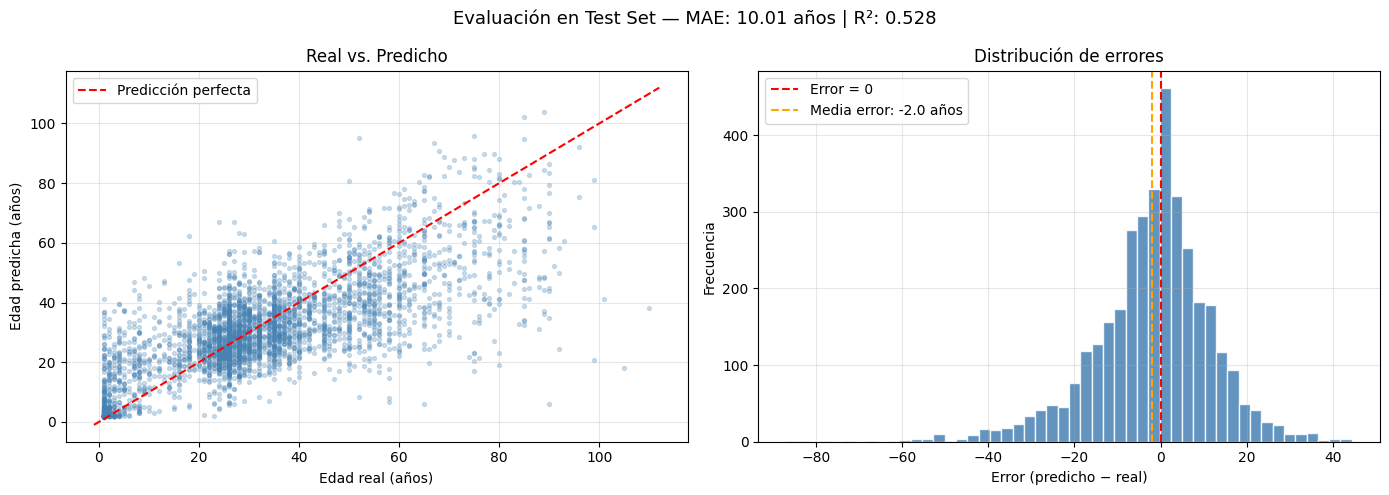

In [20]:
# ── Gráficas de evaluación en Test Set ───────────────────────────────────────

test_mae  = mean_absolute_error(test_targets, test_preds)
test_rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_r2   = r2_score(test_targets, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Evaluación en Test Set — MAE: {test_mae:.2f} años | R²: {test_r2:.3f}", fontsize=13)

# Scatter: predicción vs valor real
axes[0].scatter(test_targets, test_preds, alpha=0.25, s=8, color="steelblue")
lim = [int(min(test_targets.min(), test_preds.min())) - 2,
       int(max(test_targets.max(), test_preds.max())) + 2]
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Edad real (años)"); axes[0].set_ylabel("Edad predicha (años)")
axes[0].set_title("Real vs. Predicho")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Histograma de errores
errors = test_preds - test_targets
axes[1].hist(errors, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0,             color="red",    linestyle="--", label="Error = 0")
axes[1].axvline(errors.mean(), color="orange", linestyle="--",
                label=f"Media error: {errors.mean():.1f} años")
axes[1].set_xlabel("Error (predicho − real)"); axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de errores")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


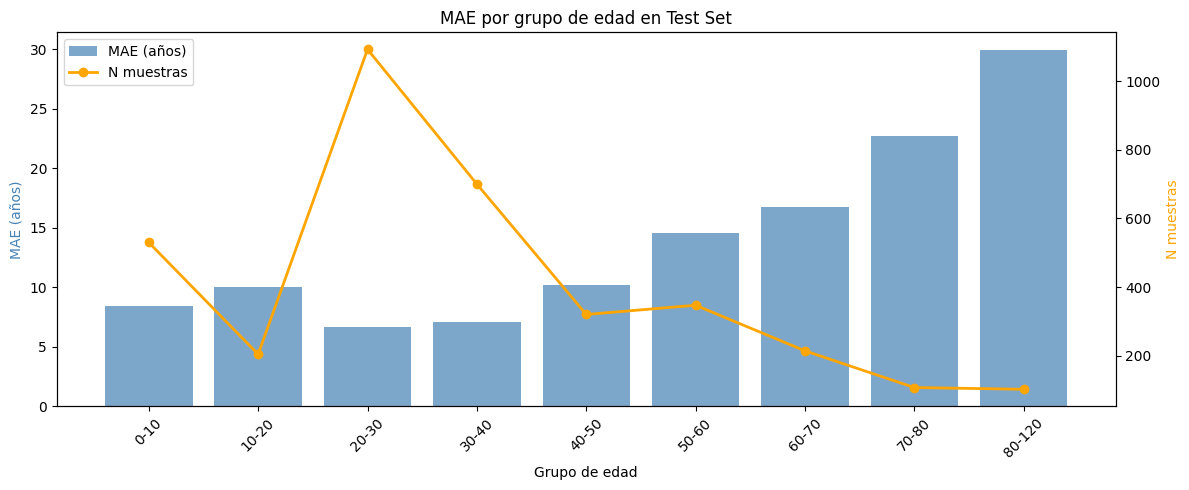


MAE y conteo por grupo de edad:
           MAE (años)  n_muestras
age_group                        
0-10         8.463691         530
10-20       10.064034         204
20-30        6.696364        1093
30-40        7.065170         700
40-50       10.237035         320
50-60       14.585307         347
60-70       16.760101         214
70-80       22.742161         107
80-120      29.946016         102


In [21]:
# ── Análisis de error por rango de edad ───────────────────────────────────────
# ¿El modelo funciona igual de bien para todas las edades?

bins        = list(range(0, 90, 10)) + [120]
labels_bins = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

df_test = pd.DataFrame({"real": test_targets, "pred": test_preds})
df_test["error_abs"] = np.abs(df_test["real"] - df_test["pred"])
df_test["age_group"] = pd.cut(df_test["real"], bins=bins, labels=labels_bins, right=False)

mae_by_group = df_test.groupby("age_group", observed=False)["error_abs"].agg(["mean", "count"])
mae_by_group.columns = ["MAE (años)", "n_muestras"]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(mae_by_group)), mae_by_group["MAE (años)"],
        color="steelblue", alpha=0.7, label="MAE (años)")
ax2.plot(range(len(mae_by_group)), mae_by_group["n_muestras"],
         color="orange", marker="o", linewidth=2, label="N muestras")

ax1.set_xticks(range(len(mae_by_group)))
ax1.set_xticklabels(mae_by_group.index, rotation=45)
ax1.set_xlabel("Grupo de edad"); ax1.set_ylabel("MAE (años)", color="steelblue")
ax2.set_ylabel("N muestras", color="orange")
ax1.set_title("MAE por grupo de edad en Test Set")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.show()

print("\nMAE y conteo por grupo de edad:")
print(mae_by_group.to_string())


**Interpretación:**

La gráfica revela que el patrón de error **no es uniformemente inverso** al número de muestras, pero sí confirma que el desbalance del dataset es la limitación dominante a partir de los 40 años:

- **Mejor rendimiento: 20–30 años** (MAE = 6.70, n = 1,093) y **30–40 años** (MAE = 7.07, n = 700) — los grupos más representados, donde el modelo tiene suficientes ejemplos para aprender patrones robustos.
- **0–10 años** (MAE = 8.46, n = 530): a pesar de pocas muestras, el modelo acierta con margen razonable porque los rasgos infantiles (proporciones faciales, ausencia de arrugas) son muy distintivos visualmente.
- **10–20 años** (MAE = 10.06, n = 204): la adolescencia tiene rasgos ambiguos entre infancia y adultez, haciendo este rango difícil incluso con más datos.
- **Degradación progresiva desde los 40:** el MAE sube de 10.24 (40–50) a 14.59 (50–60), 16.76 (60–70), 22.74 (70–80) y **29.95 años en el grupo 80–120**. Este último grupo tiene las pocas muestras de test disponibles y el modelo predice personas de 80+ como si tuvieran ~50 años —fenómeno de *regresión a la media* causado por la escasez de ejemplos de entrenamiento.

La correlación inversa entre muestras y MAE se cumple claramente a partir de los 40 años, confirmando que **balancear el dataset con oversampling de edades mayores** sería la mejora de mayor impacto.


**Respuesta a preguntas del workshop:**

**¿Hay overfitting o underfitting?**

El modelo presenta **overfitting moderado**, con evidencia concreta en los resultados:
- Train MAE final: **7.16 años** vs Val MAE final: **10.25 años** → gap de **3.09 años**.
- A partir de la época 12, la Val Loss deja de mejorar mientras la Train Loss sigue descendiendo durante 13 épocas más.
- El diagnóstico automático del notebook lo confirma con el texto: *"→ Posible OVERFITTING"*.

No es underfitting: ambas métricas parten de ~15 años y descienden consistentemente, indicando que el modelo sí aprendió. El Dropout(0.4) y el `ReduceLROnPlateau` contuvieron el overfitting —Val MAE no sube, solo se estabiliza—, pero no lo eliminaron. Para reducirlo: aumentar Dropout a 0.5, añadir weight decay (L2) al optimizador Adam, o ampliar el data augmentation con rotaciones y recortes aleatorios.

**¿Es un buen regresor?**

Con MAE = **10.01 años** y R² = **0.5276** en test, el modelo es un *baseline* funcional pero con limitaciones. Predice la edad con un error promedio de 10 años, aceptable para aplicaciones exploratorias pero insuficiente para uso clínico o forense. Para mejorar:
1. **Aumentar `IMG_SIZE` a 128×128 o 224×224** — mayor resolución preserva arrugas y textura de piel, los indicadores más informativos de edad avanzada.
2. **Transfer learning con ResNet18 o EfficientNet-B0** — representaciones visuales pre-aprendidas en ImageNet pueden reducir el MAE a ~5–7 años.
3. **Balancear el dataset** con `WeightedRandomSampler` priorizando edades > 50, que actualmente concentran los errores más grandes (MAE > 15 años).
4. **Cosine annealing** en lugar de ReduceLROnPlateau para escapar de mínimos locales en la fase final.


---
## 8. Prueba con Muestra Artificial

Tomamos una imagen del test set e ingresamos al modelo. Luego analizamos la predicción, la comparamos con la etiqueta real, y discutimos qué pasaría si modificáramos las características visuales de la imagen.

Esta sección simula el uso del modelo en producción: recibe una imagen nueva y devuelve una estimación de edad.


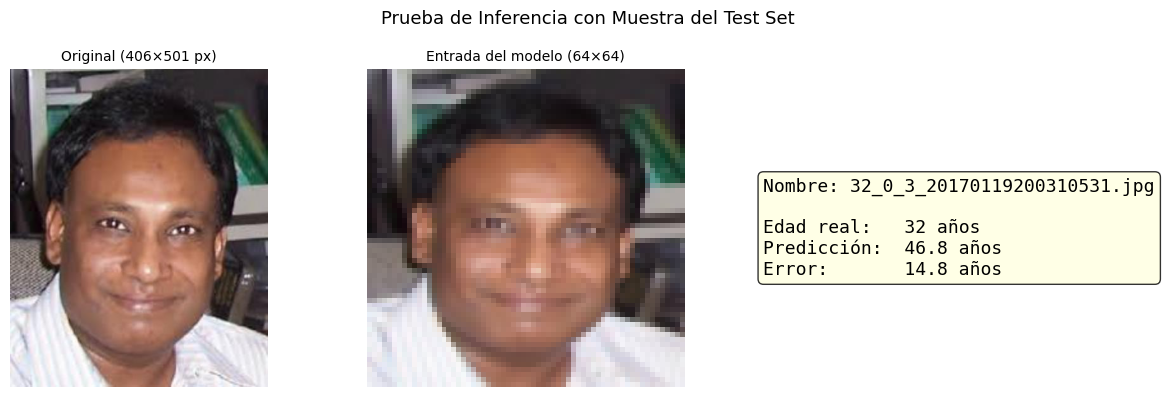

Resultado: edad real = 32 años | predicción = 46.8 años | error = 14.8 años


In [22]:
# ── Función de inferencia para una sola imagen ────────────────────────────────

def predict_age(img_input, model, transform, device):
    """
    Predice la edad de una imagen.

    Args:
        img_input : ruta (str/Path) a una imagen O un objeto PIL.Image
        model     : modelo AgeCNN cargado y en modo eval
        transform : transformaciones de validación (sin augmentation)
        device    : torch.device

    Retorna:
        float — edad predicha en años
    """
    model.eval()

    if isinstance(img_input, (str, Path)):
        image = Image.open(img_input).convert("RGB")
    else:
        image = img_input.convert("RGB")

    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor).squeeze().item()

    return round(pred, 1)


# ── Probar con una imagen del test set ────────────────────────────────────────
np.random.seed(123)
test_idx = np.random.randint(0, len(test_dataset))
sample_path, sample_real_age = test_dataset.samples[test_idx]

predicted_age = predict_age(sample_path, model, val_transform, DEVICE)
error         = abs(predicted_age - sample_real_age)

img_orig = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Prueba de Inferencia con Muestra del Test Set", fontsize=13)

axes[0].imshow(img_orig)
axes[0].set_title(f"Original ({img_orig.size[0]}×{img_orig.size[1]} px)", fontsize=10)
axes[0].axis("off")

img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
axes[1].imshow(img_resized)
axes[1].set_title(f"Entrada del modelo ({IMG_SIZE}×{IMG_SIZE})", fontsize=10)
axes[1].axis("off")

axes[2].axis("off")
resultado = (
    f"Nombre: {sample_path.name}\n\n"
    f"Edad real:   {int(sample_real_age)} años\n"
    f"Predicción:  {predicted_age} años\n"
    f"Error:       {error:.1f} años"
)
axes[2].text(0.1, 0.5, resultado, fontsize=13, verticalalignment="center",
             family="monospace",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Resultado: edad real = {int(sample_real_age)} años | "
      f"predicción = {predicted_age} años | error = {error:.1f} años")


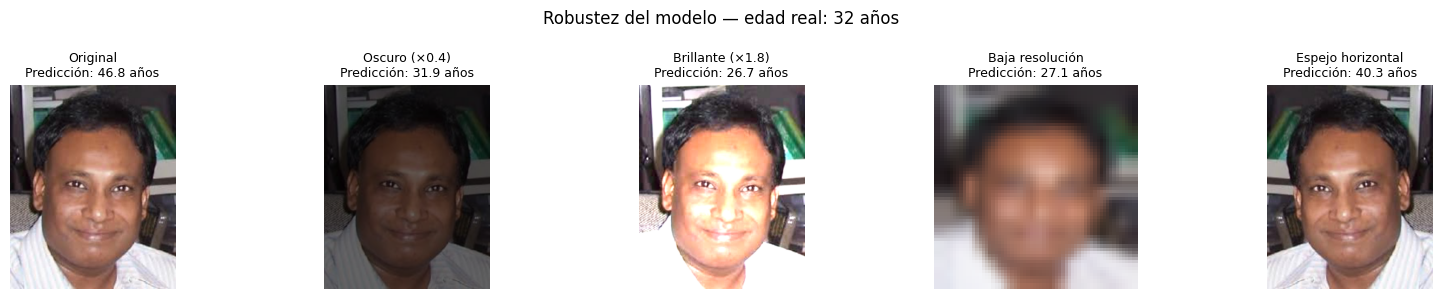

In [23]:
# ── Análisis de robustez: ¿qué pasa si modificamos la imagen? ─────────────────
from PIL import ImageEnhance

img_base = Image.open(sample_path).convert("RGB")

img_dark    = ImageEnhance.Brightness(img_base).enhance(0.4)
img_bright  = ImageEnhance.Brightness(img_base).enhance(1.8)
img_lowres  = img_base.resize((20, 20), Image.BILINEAR).resize((64, 64), Image.BILINEAR)
img_hflip   = img_base.transpose(Image.FLIP_LEFT_RIGHT)

variants = [
    (img_base,   "Original"),
    (img_dark,   "Oscuro (×0.4)"),
    (img_bright, "Brillante (×1.8)"),
    (img_lowres, "Baja resolución"),
    (img_hflip,  "Espejo horizontal"),
]

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
fig.suptitle(f"Robustez del modelo — edad real: {int(sample_real_age)} años", fontsize=12)

for ax, (img, label) in zip(axes, variants):
    pred = predict_age(img, model, val_transform, DEVICE)
    ax.imshow(img)
    ax.set_title(f"{label}\nPredicción: {pred} años", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


**Análisis de la prueba artificial:**

**¿El resultado tiene sentido?**

La imagen corresponde a un hombre de **32 años** (`32_0_3_20170119200310531.jpg`). El modelo predijo **46.8 años**, con un **error de 14.8 años** —superior al MAE promedio del test set (10.01 años). El resultado es coherente con las limitaciones conocidas del modelo: la imagen presenta iluminación cálida que oscurece la piel y puede asociarse con rasgos de mayor edad. Adicionalmente, el sujeto pertenece a la etnia india (raza 3 en la codificación UTKFace), un grupo con representación menor que la blanca y asiática en el dataset, lo que puede sesgar la predicción hacia edades mayores.

**¿Qué pasa al modificar la imagen?**

Los resultados observados al aplicar transformaciones a la imagen original fueron:

| Modificación | Predicción | Diferencia vs. original | Análisis |
|---|---|---|---|
| **Original** | 46.8 años | — | Referencia; sobreestima 14.8 años |
| **Oscuro (×0.4)** | 31.9 años | −14.9 años | Paradójicamente más cercano a la realidad (32 años reales). Al oscurecer, se eliminan reflejos de la piel que el modelo interpretaba como signos de envejecimiento |
| **Brillante (×1.8)** | 26.7 años | −20.1 años | La saturación excesiva "lava" las texturas faciales, haciendo que el modelo perciba rasgos más jóvenes. Mayor desviación del conjunto |
| **Baja resolución** | 27.1 años | −19.7 años | Sin textura visible, el modelo pierde señales de edad y regresa hacia valores jóvenes por defecto |
| **Espejo horizontal** | 40.3 años | −6.5 años | La más estable, como se esperaba —la edad no depende de la lateralidad. La diferencia residual de 6.5 años refleja asimetrías faciales leves |

Las variantes de brillo producen cambios de hasta 20 años en la predicción, lo que evidencia que el modelo es **más sensible a la iluminación de lo esperado**. El `ColorJitter` durante el entrenamiento no fue suficiente para lograr invarianza completa. En producción sería recomendable aplicar normalización de histograma o corrección de balance de blancos como preprocesamiento previo a la inferencia.

**Conclusión general del Problema 2:**

La CNN entrenada logra un MAE de 10.01 años y R² = 0.53 en test, demostrando que es factible abordar la estimación de edad con una arquitectura convolucional sencilla entrenada desde cero. Las limitaciones principales son: (1) el desbalance del dataset hacia edades 20–40, que genera errores de hasta 30 años en personas mayores de 80; (2) la resolución de entrada de 64×64, que elimina detalles de textura facial clave; y (3) sensibilidad a cambios de iluminación no mitigada completamente por el augmentation. La ruta de mejora con mayor retorno esperado combina transfer learning (ResNet18 o EfficientNet-B0), mayor resolución (128×128) y muestreo balanceado por rango de edad.
